## Inference on the Montbriò model with JAX implementation

In [8]:
import sys
import os
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)
import site
# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)

In [9]:
%matplotlib inline

In [10]:
%load_ext memory_profiler

In [42]:
import warnings
import time
import numpy as np
import seaborn as sns
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
from importlib import reload
import pandas as pd
from scipy.stats import ks_2samp, entropy
import logging
import utils
import FCD_jax
import mpr_jax
mpr_jax=reload(mpr_jax)

warnings.simplefilter("ignore")

In [12]:
import arviz as az
import graphviz
az.style.use("arviz-darkgrid")
import seaborn as sns
#optimization algorithm we will try before bayesian inference
import scipy
from scipy.optimize import differential_evolution
#numpyro is a jax-based package for inference
import numpyro as npr
from numpyro import sample, plate, handlers
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_sample

In [13]:
def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

In [14]:
@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [15]:
def plot(rv_t, r, v, bold_d, bold_t, g, close=True):
    step = 10
    fig, ax = plt.subplots(3, 1, figsize=(12, 6))
    ax[0].plot(rv_t[::step], r[::step, :], lw=0.1)
    ax[1].plot(rv_t[::step], v[::step, :], lw=0.1)
    ax[2].plot(bold_t, bold_d, lw=0.1)
    ax[0].set_ylabel("r")
    ax[1].set_ylabel("v")
    ax[2].set_ylabel("BOLD")
    # os.makedirs("data", exist_ok=True)
    # plt.savefig(f"data/control_vbi_{g:.3f}.png")
    # if close:
    #     plt.close()
    plt.show()

In [16]:
def plot_bold(bold_d, bold_t, g, close=True):
    step = 10
    fig, ax = plt.subplots(1, 1, figsize=(12, 2))
    ax.plot(bold_t, bold_d, lw=0.1)
    ax.set_ylabel("BOLD")
    # os.makedirs("data", exist_ok=True)
    # plt.savefig(f"data/control_vbi_{g:.3f}.png")
    # if close:
    #     plt.close()
    plt.show()

In [17]:
datapath = utils.DATA_ROOT
weights = np.loadtxt(datapath+"/weights.txt", delimiter=None)
nn = len(weights)
weights = jnp.array(weights)/jnp.max(weights)

In [18]:
params = {"G": 0.25, 
          "weights": weights,
          "t_end": 300000,
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0,
          "seed":42
          }

In [19]:
g=0.33
rv_t, r, v, bold_t, bold_d_obs = wrapper(g, params)

wrapper took 0.62 seconds


In [20]:
params_labels = ['$G$']
my_var_name = ['G']

In [21]:
theta_true = np.array([g])

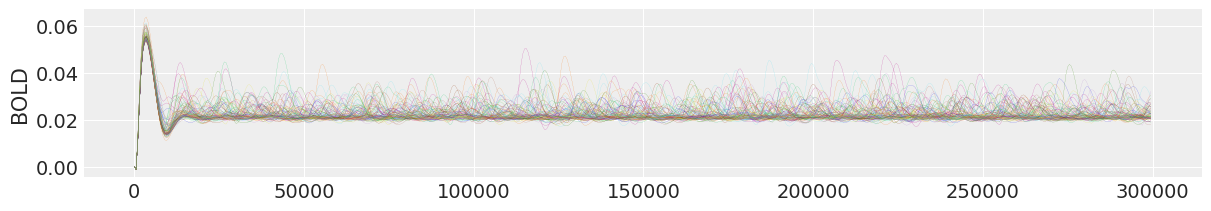

In [22]:
plot_bold(bold_d_obs, bold_t, g);

In [26]:
wwidth = 30  # must be < 60
maxNwindows = 200
olap = 0.94

In [27]:
bold_d_obs_T = bold_d_obs.T
FC_obs = FCD_jax.get_fc(bold_d_obs_T)
FCD_obs, FCvec, _ = FCD_jax.extract_FCD(bold_d_obs_T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)

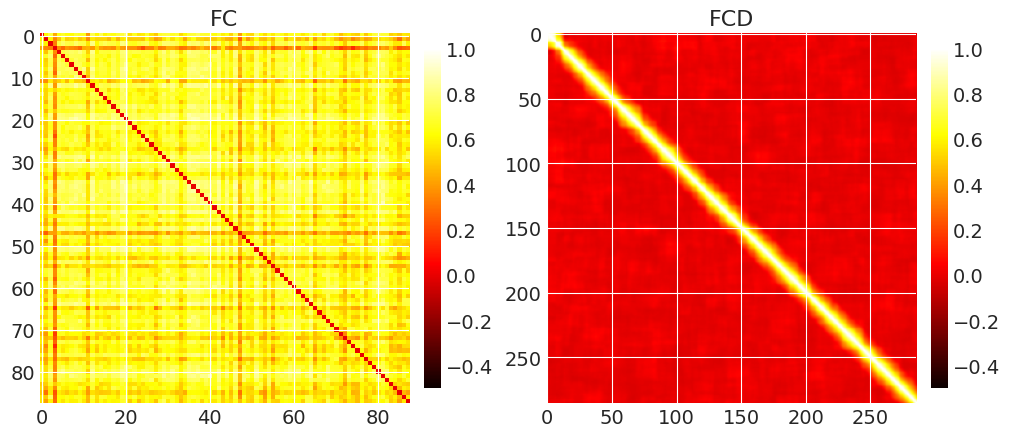

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

matrices = [FC_obs, FCD_obs]
titles = ["FC", "FCD"]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, vmin=-0.5, vmax=1, cmap='hot')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#plt.tight_layout()
plt.show()

## Inference with optimization

#### Define the losses (to quantify the distance between the observed data and the simulated ones)

In [51]:
# flatten FC_obs and FCD_obs
FC_obs_flat = np.ravel(FC_obs)
FCD_obs_flat = np.ravel(FCD_obs)

In [103]:
from importlib import reload
mpr_jax=reload(mpr_jax)

In [104]:
sde_sim = mpr_jax.MPR_sde.create(params)

In [53]:
def loss_fc_ks(G):
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fc_sim = FCD_jax.get_fc(bold_d_sim.T)
    fc_sim_flat = jnp.ravel(fc_sim)
    
    # Convert to NumPy for scipy functions
    fc_sim_flat_np = np.array(fc_sim_flat)
    obs_flat_np = np.array(FC_obs_flat)
    
    # KS distance
    KS = ks_2samp(obs_flat_np, fc_sim_flat_np)[0]
    return KS

In [54]:
def loss_fcd_ks(G):
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fcd_sim, _, _ = FCD_jax.extract_FCD(bold_d_sim.T)
    fcd_sim_flat = jnp.ravel(fcd_sim)
    
    # Convert to NumPy for scipy functions
    fcd_sim_flat_np = np.array(fcd_sim_flat)
    obs_flat_np = np.array(FCD_obs_flat)
    
    # KS distance
    KS = ks_2samp(obs_flat_np, fcd_sim_flat_np)[0]
    return KS

In [55]:
def loss_fc_kl(G):
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fc_sim = FCD_jax.get_fc(bold_d_sim.T)
    fc_sim_flat = jnp.ravel(fc_sim)
    
    # Convert to NumPy for scipy functions
    fc_sim_flat_np = np.array(fc_sim_flat)
    obs_flat_np = np.array(FC_obs_flat)

    # KL divergence
    eps = 1e-8
    bins = 50
    
    # Histogram for observed data
    p_hist, edges = np.histogram(obs_flat_np, bins=bins, density=True)
    p = (p_hist + eps) / (p_hist + eps).sum()
    
    # Histogram for the single simulated dataset
    q_hist, _ = np.histogram(fc_sim_flat_np, bins=edges, density=True)
    q = (q_hist + eps) / (q_hist + eps).sum()
    
    # KL divergence
    KL = entropy(p, q)

    return KL

In [56]:
def loss_fcd_kl(G):
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fcd_sim = FCD_jax.extract_FCD(bold_d_sim.T)
    fcd_sim_flat, _, _ = jnp.ravel(fcd_sim)
    
    # Convert to NumPy for scipy functions
    fcd_sim_flat_np = np.array(fcd_sim_flat)
    obs_flat_np = np.array(FCD_obs_flat)

    # KL divergence
    eps = 1e-8
    bins = 50
    
    # Histogram for observed data
    p_hist, edges = np.histogram(obs_flat_np, bins=bins, density=True)
    p = (p_hist + eps) / (p_hist + eps).sum()
    
    # Histogram for the single simulated dataset
    q_hist, _ = np.histogram(fcd_sim_flat_np, bins=edges, density=True)
    q = (q_hist + eps) / (q_hist + eps).sum()
    
    # KL divergence
    KL = entropy(p, q)
    
    return KL

#### Optimization step

In [57]:
def callback_function(intermediate_result, convergence=None): 
    trace_loss.append(intermediate_result[0])  
    trace_prms.append(intermediate_result[1:]) 

In [58]:
Niter = 1

def callback_function_params_only(xk, convergence=None):
    global Niter
    if convergence is None:
        logging.info('{0:4d}   {1: 3.6f}'.format(
            Niter,
            xk[0]))
    else:
        logging.info('{0:4d}   {1: 3.6f}   {6: 1.3f}'.format(
            Niter,
            xk[0],
            convergence))
    Niter += 1

In [59]:
trace_loss = []
trace_prms = []

bounds = [(0.0, 0.999999)]

In [62]:
maxiter = 1000 #it wa 1000
popsize = 5
callback = callback_function #or callbackfunction

In [63]:
start_time = time.time()
res = differential_evolution(loss_fc_ks, 
                             bounds=bounds, 
                             popsize=popsize, 
                             maxiter=maxiter, 
                             callback=callback, 
                             polish=False,
                             seed=0)
print("Scipy DE took (sec):" , (time.time() - start_time))

Scipy DE took (sec): 3532.698558330536


In [64]:
res.x

array([0.33771205])

In [65]:
trace_loss = []
trace_prms = []

bounds = [(0.0, 0.999999)]

start_time = time.time()
res_fcd_ks = differential_evolution(loss_fcd_ks, 
                             bounds=bounds, 
                             popsize=popsize, 
                             maxiter=maxiter, 
                             callback=callback, 
                             polish=False,
                             seed=0)
print("Scipy DE took (sec):" , (time.time() - start_time))

Scipy DE took (sec): 24548.267315626144


In [66]:
res_fcd_ks.x

array([0.07711231])

In [67]:
trace_loss = []
trace_prms = []

bounds = [(0.0, 0.999999)]

start_time = time.time()
res_fc_kl = differential_evolution(loss_fc_kl, 
                             bounds=bounds, 
                             popsize=popsize, 
                             maxiter=maxiter, 
                             callback=callback, 
                             polish=False,
                             seed=0)
print("Scipy DE took (sec):" , (time.time() - start_time))

NameError: name 'mixiter' is not defined

In [ ]:
res_fc_kl.x

In [ ]:
trace_loss = []
trace_prms = []

bounds = [(0.0, 0.999999)]

start_time = time.time()
res_fcd_kl = differential_evolution(loss_fcd_kl, 
                             bounds=bounds, 
                             popsize=popsize, 
                             maxiter=maxiter, 
                             callback=callback, 
                             polish=False,
                             seed=0)
print("Scipy DE took (sec):" , (time.time() - start_time))

In [ ]:
res_fcd_kl

## Bayesian Inference

In [105]:
scale = 1 

In [106]:
def model_fc(sde_sim,FC_obs_flat):
    G = npr.sample('G',dist.HalfNormal(scale=scale))
    param_samples = [G]
    data_sim = sde_sim.run({"G": G})
    bold_d_sim = data_sim["bold_d"]
    fc_sim = FCD_jax.get_fc(bold_d_sim.T)
    fc_sim_flat = jnp.ravel(fc_sim)
    
    # Convert to NumPy for scipy functions
    fc_sim_flat_np = np.array(fc_sim_flat)
    obs_flat_np = np.array(FC_obs_flat)

    # Likelihood
    with npr.plate("data", size=FC_obs_flat.shape[0]):
        npr.sample("fc_obs", 
                   dist.Normal(loc=fc_sim_flat, scale=0.1),  # adjust noise scale
                   obs=FC_obs_flat)

In [107]:
with npr.handlers.seed(rng_seed=1):
    trace = npr.handlers.trace(model_fc).get_trace(sde_sim,FC_obs_flat)
print(npr.util.format_shapes(trace))

Trace Shapes:       
 Param Sites:       
Sample Sites:       
       G dist      |
        value      |
   data plate 7744 |
  fc_obs dist 7744 |
        value 7744 |


#### Prior predictive checks

In [108]:
rng_key = jax.random.PRNGKey(0) 

In [109]:
n_prior = 10 # number of samples from prior

prior_predictive = Predictive(model_fc, num_samples=n_prior)

_, rng_key = jax.random.split(rng_key)
prior_predictions = prior_predictive(rng_key, sde_sim,FC_obs_flat)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape float32[]
This occurred in the item() method of jax.Array
The error occurred while tracing the function <lambda> at /home/monica/anaconda3/envs/vbi/lib/python3.10/site-packages/jax/_src/lax/control_flow/loops.py:2485 for scan. This value became a tracer due to JAX operations on these lines:

  operation a:f32[] = mul b 1.0:f32[]
    from line /tmp/ipykernel_2124052/2122665658.py:2 (model_fc)

  operation a:f32[] = add 0.0:f32[] b
    from line /tmp/ipykernel_2124052/2122665658.py:2 (model_fc)

  operation b:f32[88] = pjit[
  name=_uniform
  jaxpr={ lambda ; a:key<fry>[] c:f32[] d:f32[]. let
      e:f32[] = convert_element_type[new_dtype=float32 weak_type=False] c
      f:f32[] = convert_element_type[new_dtype=float32 weak_type=False] d
      g:f32[1] = broadcast_in_dim[
        broadcast_dimensions=()
        shape=(1,)
        sharding=None
      ] e
      h:f32[1] = br